# 06 - Evaluación comparativa de modelos para predicción de AKI

## Objetivo
El objetivo de este notebook fue realizar una evaluación comparativa más profunda de los modelos entrenados en la fase anterior, utilizando métricas adecuadas para problemas de clasificación desbalanceados, representaciones gráficas del rendimiento y un análisis específico del efecto del umbral de clasificación sobre la utilidad clínica de los modelos.

Esta etapa fue especialmente importante porque permitió pasar de una lectura numérica básica a una interpretación metodológica más rica, integrando discriminación global, matrices de confusión y análisis de sensibilidad al umbral de decisión.

### 1. Importar librerías
Se importaron las librerías necesarias para:

- manipulación de datos (`pandas`, `numpy`)
- visualización (`matplotlib`, `seaborn`)
- carga de modelos entrenados (`joblib`)
- reconstrucción del split (`train_test_split`)
- cálculo de métricas y representaciones de evaluación (`roc_auc_score`, `precision_score`, `recall_score`, `f1_score`, `confusion_matrix`, `ConfusionMatrixDisplay`, `roc_curve`, `classification_report`)

Estas herramientas permitieron realizar una evaluación integrada de los modelos desde distintas perspectivas: numérica, gráfica y clínica.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    classification_report
)

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

sns.set(style="whitegrid")

### 2. Cargar el dataset final de modelado
Se cargó el archivo `aki_dataset_model_ready.csv`, que contenía el conjunto final de variables definido en el notebook anterior.

In [2]:
file_path = "../data/processed/aki_dataset_model_ready.csv"
df = pd.read_csv(file_path)

print("Dataset cargado correctamente.")
print(f"Filas: {df.shape[0]}")
print(f"Columnas: {df.shape[1]}")

Dataset cargado correctamente.
Filas: 1175
Columnas: 14


### 3. Separación en `X` e `y`
La separación explícita de predictores y outcome es el formato estándar requerido para reconstruir el mismo conjunto de prueba y generar nuevas predicciones a partir de los modelos entrenados.

Este paso permitió reutilizar el dataset final de manera consistente con la estructura empleada en el notebook 05.


In [3]:
target_col = "AKI_48h"
feature_cols = [col for col in df.columns if col != target_col]

X = df[feature_cols].copy()
y = df[target_col].copy()

print("Dimensiones de X:", X.shape)
print("Dimensiones de y:", y.shape)

Dimensiones de X: (1175, 13)
Dimensiones de y: (1175,)


### 4. Reconstrucción del split/train
Se reconstruyó la partición original de entrenamiento y prueba utilizando exactamente los mismos parámetros que en el notebook anterior:

- `test_size = 0.2`
- `random_state = 42`
- `stratify = y`

Esto era necesario para garantizar que las predicciones y métricas obtenidas en este notebook correspondieran exactamente al mismo conjunto de prueba utilizado durante el entrenamiento inicial.

Este paso permitió trabajar sobre un escenario de evaluación idéntico al del notebook 05, preservando la reproducibilidad del análisis.


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (940, 13)
X_test: (235, 13)
y_train: (940,)
y_test: (235,)


### 5. Carga de modelos entrenados
Se cargaron desde la carpeta `models/` los pipelines previamente guardados:

- `logreg_pipeline.pkl`
- `rf_pipeline.pkl`

In [5]:
logreg_pipeline = joblib.load("../models/logreg_pipeline.pkl")
rf_pipeline = joblib.load("../models/rf_pipeline.pkl")

print("Modelos cargados correctamente.")

Modelos cargados correctamente.


### 6. Predicciones y probabilidades
Para ambos modelos se obtuvieron:

- las clases predichas (`predict`)
- las probabilidades estimadas para la clase positiva (`predict_proba`)

Las clases predichas permiten construir matrices de confusión y calcular métricas basadas en decisiones binarias, mientras que las probabilidades son necesarias para calcular ROC-AUC y construir curvas ROC.

La distinción entre predicciones binarias y probabilidades fue esencial en este notebook, ya que uno de los principales hallazgos fue precisamente la discrepancia entre buena discriminación probabilística y bajo rendimiento con el umbral estándar.


In [6]:
# Regresión logística
y_pred_logreg = logreg_pipeline.predict(X_test)
y_proba_logreg = logreg_pipeline.predict_proba(X_test)[:, 1]

# Random Forest
y_pred_rf = rf_pipeline.predict(X_test)
y_proba_rf = rf_pipeline.predict_proba(X_test)[:, 1]

### 7. Cálculo de métricas comparativas
Se construyó una tabla comparativa (`results_df`) con las métricas principales de ambos modelos:

- ROC-AUC
- precision
- recall
- F1-score

#### Resultados obtenidos
- **Random Forest**
  - ROC-AUC = 0.895
  - Precision = 0.000
  - Recall = 0.000
  - F1 = 0.000

- **Regresión Logística**
  - ROC-AUC = 0.747
  - Precision = 0.061
  - Recall = 0.667
  - F1 = 0.111

Estas métricas fueron seleccionadas por ser más apropiadas que la accuracy en un problema con una clase positiva muy poco frecuente.

Los resultados mostraron una diferencia entre ambos modelos:
- el **Random Forest** presentó una mejor capacidad global de discriminación, reflejada en un ROC-AUC superior.
- la **Regresión Logística** presentó mejor capacidad de detección de casos positivos con el umbral estándar.

Este hallazgo fue metodológicamente muy relevante, ya que puso de manifiesto que el mejor modelo depende de la métrica priorizada.


In [7]:
results_df = pd.DataFrame({
    "Modelo": ["Regresión Logística", "Random Forest"],
    "ROC_AUC": [
        roc_auc_score(y_test, y_proba_logreg),
        roc_auc_score(y_test, y_proba_rf)
    ],
    "Precision": [
        precision_score(y_test, y_pred_logreg, zero_division=0),
        precision_score(y_test, y_pred_rf, zero_division=0)
    ],
    "Recall": [
        recall_score(y_test, y_pred_logreg, zero_division=0),
        recall_score(y_test, y_pred_rf, zero_division=0)
    ],
    "F1_score": [
        f1_score(y_test, y_pred_logreg, zero_division=0),
        f1_score(y_test, y_pred_rf, zero_division=0)
    ]
})

results_df.sort_values(by="ROC_AUC", ascending=False)

,Modelo,ROC_AUC,Precision,Recall,F1_score
1,Random Forest,0.895197,0.000000,0.000000,0.000000
0,Regresión Logística,0.747453,0.060606,0.666667,0.111111


### 8. Matríz de confusión de la regresíon logística
Se construyó y representó gráficamente la matriz de confusión de la regresión logística.

La matriz mostró:
- 167 verdaderos negativos
- 62 falsos positivos
- 2 falsos negativos
- 4 verdaderos positivos

La matriz de confusión permite entender de forma directa qué tipo de errores comete el modelo.

La regresión logística mostró un comportamiento relativamente sensible, ya que logró identificar 4 de los 6 casos positivos del conjunto de prueba. No obstante, este desempeño se consiguió a costa de un número elevado de falsos positivos. Desde una perspectiva clínica, esto sugiere que el modelo podría ser útil como herramienta de alerta o cribado, aunque con una especificidad limitada.

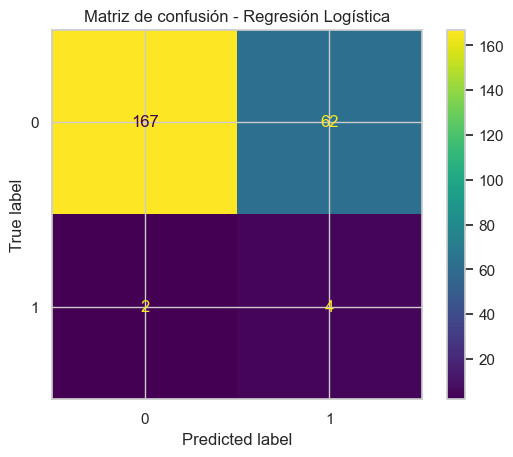

In [8]:
cm_logreg = confusion_matrix(y_test, y_pred_logreg)

disp_logreg = ConfusionMatrixDisplay(confusion_matrix=cm_logreg)
disp_logreg.plot()
plt.title("Matriz de confusión - Regresión Logística")
plt.show()

### 9. Matríz de confusión del Random Forest
Se construyó y representó gráficamente la matriz de confusión del Random Forest con el umbral estándar de 0.5.

La matriz mostró:
- 228 verdaderos negativos
- 1 falso positivo
- 6 falsos negativos
- 0 verdaderos positivos

La comparación directa con la matriz de la regresión logística era necesaria para entender cómo cambia el patrón de errores entre modelos.

El Random Forest mostró un comportamiento extremadamente conservador bajo el umbral estándar. Aunque casi no generó falsos positivos, no detectó ningún caso positivo. Desde el punto de vista clínico, este comportamiento limita mucho su utilidad si se mantiene el umbral de 0.5.

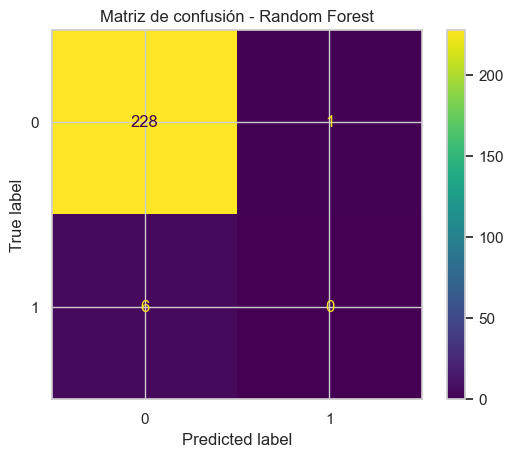

In [9]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf)
disp_rf.plot()
plt.title("Matriz de confusión - Random Forest")
plt.show()

### 10 Curvas ROC comparativas
Se calcularon y representaron las curvas ROC de ambos modelos, junto con sus valores de AUC.

**Resultados**
- Regresión Logística: AUC = 0.747
- Random Forest: AUC = 0.895

La curva ROC permite evaluar la capacidad discriminativa global de los modelos sin depender de un umbral de clasificación concreto.

La curva del Random Forest se situó claramente por encima de la de la regresión logística durante gran parte del rango de tasas de falsos positivos. Esto confirmó que el Random Forest ordena mejor a los pacientes según su riesgo relativo de desarrollar AKI.

Este resultado resolvió la aparente contradicción observada previamente: el Random Forest podía tener una discriminación global superior y, sin embargo, un rendimiento muy pobre como clasificador binario bajo el umbral estándar. En otras palabras, el modelo sí distinguía mejor entre positivos y negativos en términos probabilísticos, pero no asignaba probabilidades suficientemente altas como para producir clasificaciones positivas con un threshold de 0.5.


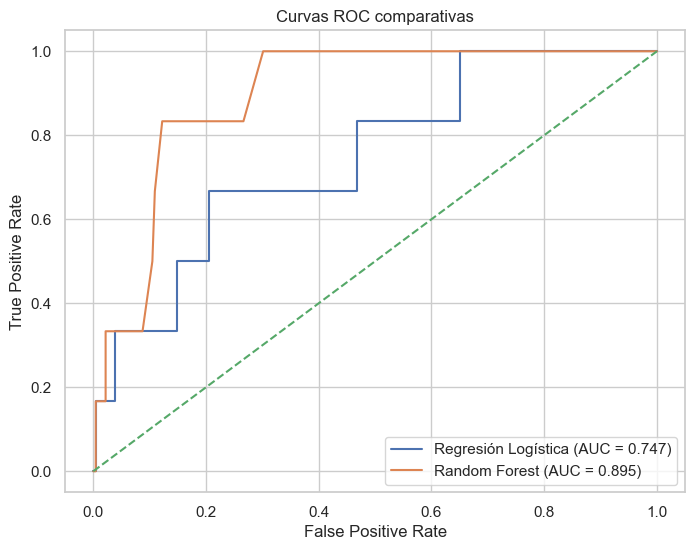

In [10]:
fpr_logreg, tpr_logreg, _ = roc_curve(y_test, y_proba_logreg)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)

roc_auc_logreg = roc_auc_score(y_test, y_proba_logreg)
roc_auc_rf = roc_auc_score(y_test, y_proba_rf)

plt.figure(figsize=(8, 6))
plt.plot(fpr_logreg, tpr_logreg, label=f"Regresión Logística (AUC = {roc_auc_logreg:.3f})")
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {roc_auc_rf:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curvas ROC comparativas")
plt.legend()
plt.show()

### 11. Reportes de clasificación
Se imprimieron los `classification_report` de ambos modelos.

Estos reportes permiten disponer de una visión detallada del rendimiento por clase, complementando las métricas resumidas y las matrices de confusión.

Los reportes reforzaron la lectura previa:
- la regresión logística fue más útil para identificar la clase positiva,
- mientras que el Random Forest quedó penalizado por no emitir predicciones positivas bajo su configuración inicial.


In [11]:
print("=== Classification report - Regresión Logística ===")
print(classification_report(y_test, y_pred_logreg, zero_division=0))

print("\n=== Classification report - Random Forest ===")
print(classification_report(y_test, y_pred_rf, zero_division=0))

=== Classification report - Regresión Logística ===
              precision    recall  f1-score   support

           0       0.99      0.73      0.84       229
           1       0.06      0.67      0.11         6

    accuracy                           0.73       235
   macro avg       0.52      0.70      0.48       235
weighted avg       0.96      0.73      0.82       235


=== Classification report - Random Forest ===
              precision    recall  f1-score   support

           0       0.97      1.00      0.98       229
           1       0.00      0.00      0.00         6

    accuracy                           0.97       235
   macro avg       0.49      0.50      0.49       235
weighted avg       0.95      0.97      0.96       235



### 12. Análisis de umbral para Random Forest

Se realizó un análisis específico del Random Forest evaluando varios umbrales de clasificación:

- 0.50
- 0.30
- 0.20
- 0.10

Para cada uno se calcularon:
- precision
- recall
- F1-score
- ROC-AUC

#### Resultados obtenidos
- **Threshold 0.50**
  - Precision = 0.000
  - Recall = 0.000
  - F1 = 0.000

- **Threshold 0.30**
  - Precision = 0.500
  - Recall = 0.167
  - F1 = 0.250

- **Threshold 0.20**
  - Precision = 0.286
  - Recall = 0.333
  - F1 = 0.308

- **Threshold 0.10**
  - Precision = 0.182
  - Recall = 0.333
  - F1 = 0.235

### Justificación
Dado que el Random Forest mostró un ROC-AUC elevado, pero recall nulo con el umbral estándar, resultaba metodológicamente necesario comprobar si su utilidad clínica mejoraba al modificar el punto de corte de decisión.

### Interpretación
Este análisis mostró que el comportamiento del Random Forest dependía de forma muy marcada del umbral utilizado. Al reducir el threshold, el modelo comenzó a identificar casos positivos, lo que confirmó que el problema no residía tanto en su capacidad de discriminación como en una regla de decisión demasiado conservadora.

El mejor equilibrio entre precision, recall y F1 se observó en el umbral de **0.20**, donde:
- detectó 2 de los 6 casos positivos,
- mantuvo una precisión moderada,
- y alcanzó el mayor F1-score entre los thresholds evaluados.

Este resultado sugiere que, para este problema concreto, el umbral estándar de 0.5 no es adecuado para traducir la capacidad discriminativa del Random Forest en una utilidad clínica razonable.


In [12]:
thresholds = [0.50, 0.30, 0.20, 0.10]

threshold_results = []

for thr in thresholds:
    y_pred_thr = (y_proba_rf >= thr).astype(int)

    threshold_results.append({
        "Threshold": thr,
        "Precision": precision_score(y_test, y_pred_thr, zero_division=0),
        "Recall": recall_score(y_test, y_pred_thr, zero_division=0),
        "F1_score": f1_score(y_test, y_pred_thr, zero_division=0),
        "ROC_AUC": roc_auc_score(y_test, y_proba_rf)
    })

threshold_df = pd.DataFrame(threshold_results)
threshold_df

,Threshold,Precision,Recall,F1_score,ROC_AUC
0,0.5,0.000000,0.000000,0.000000,0.895197
1,0.3,0.500000,0.166667,0.250000,0.895197
2,0.2,0.285714,0.333333,0.307692,0.895197
3,0.1,0.181818,0.333333,0.235294,0.895197


### 13. Matrices de confusión del Random Forest con distintos umbrales
Se generaron matrices de confusión del Random Forest para cada umbral evaluado.

#### Resultados principales
- **0.30**
  - TN = 228
  - FP = 1
  - FN = 5
  - TP = 1

- **0.20**
  - TN = 224
  - FP = 5
  - FN = 4
  - TP = 2

- **0.10**
  - TN = 220
  - FP = 9
  - FN = 4
  - TP = 2

### Justificación
Las matrices de confusión permitieron observar de forma tangible cómo cambia el balance entre detección de positivos y falsas alarmas al modificar el umbral.

### Interpretación
El análisis mostró que al reducir el threshold:
- aumentaba la sensibilidad del modelo,
- pero también aumentaban los falsos positivos.

El umbral de 0.20 pareció ofrecer el mejor compromiso, ya que mejoró el recall sin deteriorar en exceso la precisión. En cambio, reducir aún más el umbral hasta 0.10 ya no mejoró el recall respecto a 0.20, pero sí incrementó los falsos positivos, empeorando el F1-score.


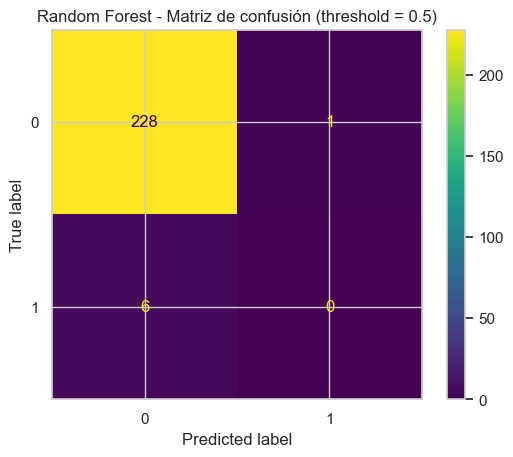

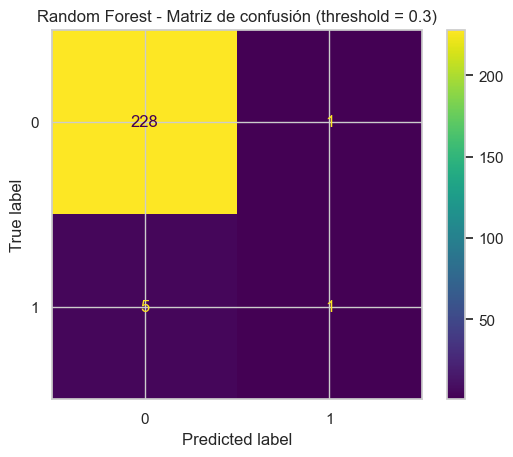

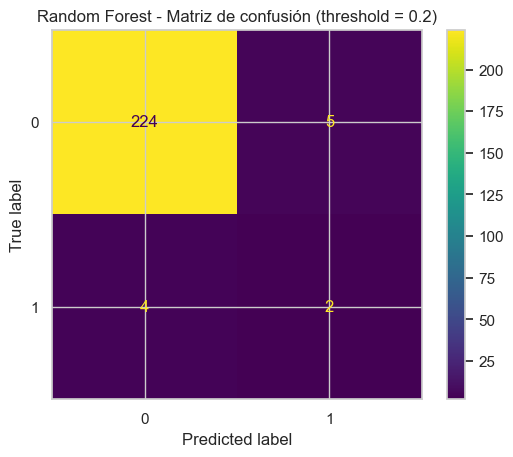

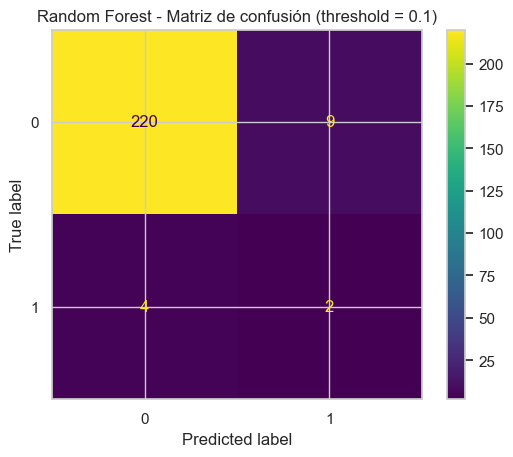

In [13]:
for thr in thresholds:
    y_pred_thr = (y_proba_rf >= thr).astype(int)
    cm_thr = confusion_matrix(y_test, y_pred_thr)

    disp = ConfusionMatrixDisplay(confusion_matrix=cm_thr)
    disp.plot()
    plt.title(f"Random Forest - Matriz de confusión (threshold = {thr})")
    plt.show()

### 14. Visualización del efecto del umbral sobre recall y precisión
Se representó gráficamente cómo variaban recall, precision y F1-score del Random Forest en función del threshold.

#### Justificación
La visualización facilita comprender el trade-off entre sensibilidad y precisión de forma más intuitiva que una tabla numérica.

#### Interpretación
El gráfico mostró que:
- con threshold 0.5, el modelo no detecta positivos;
- con threshold 0.3, gana precisión pero con baja sensibilidad;
- con threshold 0.2, alcanza el mejor equilibrio global;
- con threshold 0.1, no mejora la sensibilidad y sí reduce la precisión.

Este gráfico refuerza la idea de que la utilidad clínica de un modelo desbalanceado no puede evaluarse únicamente con el umbral estándar.


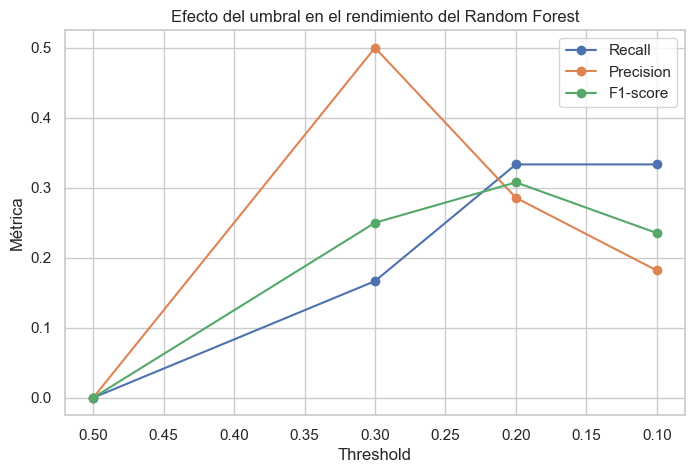

In [14]:
plt.figure(figsize=(8, 5))
plt.plot(threshold_df["Threshold"], threshold_df["Recall"], marker="o", label="Recall")
plt.plot(threshold_df["Threshold"], threshold_df["Precision"], marker="o", label="Precision")
plt.plot(threshold_df["Threshold"], threshold_df["F1_score"], marker="o", label="F1-score")
plt.gca().invert_xaxis()
plt.xlabel("Threshold")
plt.ylabel("Métrica")
plt.title("Efecto del umbral en el rendimiento del Random Forest")
plt.legend()
plt.show()

**Interpretación del análisis de umbral**

En problemas clínicos desbalanceados, el umbral estándar de 0.5 no siempre resulta adecuado. Analizar distintos puntos de corte permite valorar si un modelo inicialmente conservador puede volverse más útil desde el punto de vista clínico al priorizar sensibilidad sobre especificidad.

### 15. Comparación final resumida
Se presentaron de forma conjunta:
- los resultados base de ambos modelos,
- y los resultados del Random Forest con distintos umbrales.

Agrupar estos resultados en una única sección facilitó la comparación global y permitió construir una conclusión integrada.

El resumen final mostró claramente que:
- el Random Forest fue superior en discriminación global,
- la regresión logística fue superior en sensibilidad clínica con la configuración base,
- y el Random Forest mejoró su rendimiento práctico al ajustar el umbral.


In [15]:
print("=== Resultados base ===")
display(results_df.sort_values(by="ROC_AUC", ascending=False))

print("\n=== Resultados Random Forest con distintos umbrales ===")
display(threshold_df)

=== Resultados base ===


,Modelo,ROC_AUC,Precision,Recall,F1_score
1,Random Forest,0.895197,0.000000,0.000000,0.000000
0,Regresión Logística,0.747453,0.060606,0.666667,0.111111



=== Resultados Random Forest con distintos umbrales ===


,Threshold,Precision,Recall,F1_score,ROC_AUC
0,0.5,0.000000,0.000000,0.000000,0.895197
1,0.3,0.500000,0.166667,0.250000,0.895197
2,0.2,0.285714,0.333333,0.307692,0.895197
3,0.1,0.181818,0.333333,0.235294,0.895197


### 16. Conclusiones del notebook
En este notebook se realizó una evaluación comparativa más detallada de los modelos entrenados para la predicción de AKI.

Los principales hallazgos fueron:

- el Random Forest presentó una mejor capacidad global de discriminación según ROC-AUC,
- la regresión logística mostró un mejor comportamiento en términos de recall bajo el umbral estándar,
- el Random Forest no detectó casos positivos con threshold = 0.5, pese a su buen ROC-AUC,
- y el análisis de umbral permitió explorar si su utilidad clínica podía mejorar modificando el punto de corte de clasificación.

Estos resultados refuerzan la idea de que, en problemas desbalanceados y clínicamente sensibles, la evaluación de modelos no debe depender únicamente del umbral por defecto ni de una sola métrica de rendimiento.

Este notebook permitió profundizar en la evaluación comparativa de los modelos entrenados y obtener una lectura más rica del rendimiento que la proporcionada por una única tabla de métricas.

### Hallazgos principales
- el Random Forest mostró mejor capacidad global de discriminación según ROC-AUC;
- la regresión logística mostró mejor recall con el umbral estándar;
- el umbral 0.5 resultó inadecuado para explotar la capacidad predictiva del Random Forest en este problema;
- y el análisis de threshold indicó que un valor de 0.20 ofrecía el mejor equilibrio entre precision, recall y F1-score entre los puntos de corte analizados.

### Conclusión metodológica principal
La evaluación puso de manifiesto que, en problemas clínicos desbalanceados, no basta con comparar modelos usando únicamente un umbral estándar o una sola métrica. La utilidad real de un modelo depende tanto de su capacidad discriminativa como de la regla de decisión empleada para convertir probabilidades en clasificaciones binarias.

Este hallazgo justifica plenamente la fase siguiente del trabajo, centrada en la interpretación clínica de los modelos y en el análisis de las variables que más contribuyen a la predicción de AKI.
